## Imports

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

import kagglehub
import pandas as pd
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator    

## Load The Data

In [2]:
train_dir = '/kaggle/input/cloiud-dataset/clouds_train'
test_dir = '/kaggle/input/cloiud-dataset/clouds_test'

In [3]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2  # Use 20% of training data for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 382 images belonging to 7 classes.


TypeError: listdir: path should be string, bytes, os.PathLike, integer or None, not DirectoryIterator

In [6]:
num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")
print(f"Class indices: {train_generator.class_indices}")

Number of classes: 7
Class indices: {'cirriform clouds': 0, 'clear sky': 1, 'cumulonimbus clouds': 2, 'cumulus clouds': 3, 'high cumuliform clouds': 4, 'stratiform clouds': 5, 'stratocumulus clouds': 6}


## Model

In [14]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)

Epoch 1/50


I0000 00:00:1762324639.617885    6159 service.cc:148] XLA service 0x798894002ad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762324639.617946    6159 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762324639.951914    6159 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/12 ━━━━━━━━━━━━━━━━━━━━ 1:28 8s/step - accuracy: 0.1250 - loss: 1.9569

I0000 00:00:1762324644.355819    6159 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1950 - loss: 2.0635 - val_accuracy: 0.2826 - val_loss: 1.8136
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 519ms/step - accuracy: 0.2912 - loss: 1.8064 - val_accuracy: 0.3261 - val_loss: 1.7517
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 473ms/step - accuracy: 0.3291 - loss: 1.7414 - val_accuracy: 0.2826 - val_loss: 1.5857
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 473ms/step - accuracy: 0.3300 - loss: 1.5716 - val_accuracy: 0.4239 - val_loss: 1.4210
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 484ms/step - accuracy: 0.4240 - loss: 1.4223 - val_accuracy: 0.4891 - val_loss: 1.3509
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 490ms/step - accuracy: 0.4293 - loss: 1.3498 - val_accuracy: 0.3913 - val_loss: 1.5444
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 477ms/step - accuracy: 0.4062 - loss: 1.3569 - val_accuracy: 0.3696 - val_loss: 1.3477
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 480ms/step - accuracy: 0.4193 - loss: 1.3558 - val_accuracy: 0.4783 - val_lo

## Results

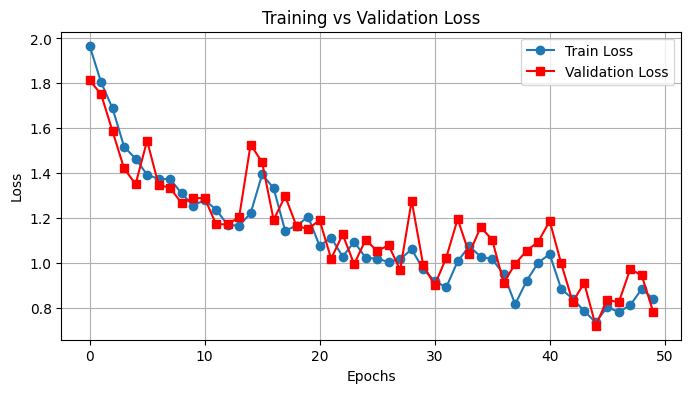

In [20]:
import matplotlib.pyplot as plt
# Loss Plot
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', color='red')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
     

In [38]:
model = keras.models.load_model("cloud_classifier_model.h5") 

print("\nModel saved as 'cloud_classifier_model.h5'")


Model saved as 'cloud_classifier_model.h5'


In [39]:
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step


In [40]:
true_classes = test_generator.classes
class_labels = list(train_generator.class_indices.keys())

In [43]:
train_generator, validation_generator, test_generator
model = keras.models.load_model("cloud_classifier_model.h5")    # trained model
class_names = num_classes


## Classification Report

✅ Model loaded from 'cloud_classifier_model.h5'
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
                        precision    recall  f1-score   support

      cirriform clouds       0.68      0.44      0.54        77
             clear sky       0.92      0.88      0.90        64
   cumulonimbus clouds       0.53      0.73      0.62        11
        cumulus clouds       0.79      0.74      0.76       120
high cumuliform clouds       0.60      0.74      0.66       103
     stratiform clouds       0.87      0.65      0.74        40
  stratocumulus clouds       0.58      0.75      0.65        71

              accuracy                           0.70       486
             macro avg       0.71      0.70      0.70       486
          weighted avg       0.72      0.70      0.70       486



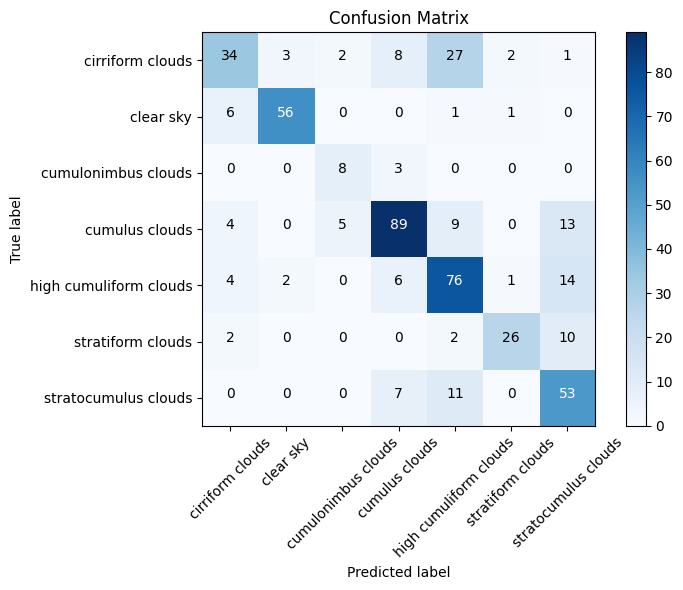

In [47]:
import numpy as np
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1️⃣ Load your model
model = keras.models.load_model("cloud_classifier_model.h5")
print("✅ Model loaded from 'cloud_classifier_model.h5'")

# 2️⃣ Predict on test data
test_generator.reset()
steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
y_prob = model.predict(test_generator, steps=steps, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# 3️⃣ Get true labels and class names
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 4️⃣ Print classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# 5️⃣ Confusion matrix (simple blue)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Annotate cell counts
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()
